# SIGAP AI - Analysis Sentiment Model Building


### Import Library

In [175]:
# Common
import os
import re
import time
import pandas as pd

# Model
from sklearn.model_selection import train_test_split

# Preprocessing
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter


### Path Configuration


In [176]:
# KONFIGURASI PATH
BASE_DIR   = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "dataset")

DIPAWIDIA_PATH = os.path.join(DATA_DIR, "dipawidia_reviews.csv")
GMAPS_PATH = os.path.join(DATA_DIR, "gmaps_reviews.csv")
PRDECT_PATH = os.path.join(DATA_DIR, "prdect-id_reviews.csv")


In [177]:

# Tambahan path dataset F&B
RESTAURANT_10000_PATH = os.path.join(DATA_DIR, "10000restaurant_reviews.csv")
ABSA_RESTAURANT_PATH = os.path.join(DATA_DIR, "absaRestaurant_reviews.csv")
GMAPS_RESTAURANT2_PATH = os.path.join(DATA_DIR, "gmaps_reviews2.csv")
GMAPS_KAGGLE_PATH = os.path.join(DATA_DIR, "gmaps-kaggle_reviews.csv")
MENDELEY_CUSTOMER_PATH = os.path.join(DATA_DIR, "mendeley-customer_reviews.csv")

NDJEDIR_PATH = os.path.join(DATA_DIR, "Ndjedir_reviews.csv")
UMAYUMCHA_PATH = os.path.join(DATA_DIR, "umayumcha_reviews.csv")
BITTERSWEET_PATH = os.path.join(DATA_DIR, "cp-bittersweet_reviews.csv")
FORE_COFFEE_PATH = os.path.join(DATA_DIR, "fore-coffe_reviews.csv")

# Path tambahan dataset Google Play Review F&B
GOFOOD_GOOGLEPLAY_PATH = os.path.join(DATA_DIR, "gofood_googleplay_reviews.csv")
GRABFOOD_GOOGLEPLAY_PATH = os.path.join(DATA_DIR, "grabfood_googleplay_reviews.csv")


### Basic Cleaning + Merge Dataset


In [178]:
# Basic Function

EMPTY_LIKE = {"", "null", "nan", "none"}

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()
    if text.lower() in EMPTY_LIKE:
        return ""
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def extract_rating(value):
    value = str(value).strip()
    if re.fullmatch(r'[1-5](\.0)?', value):
        return int(float(value))
    return pd.NA

def clean_reviews_date(value):
    value = clean_text(value)
    return value if value else "unknown"


def first_non_empty(*values):
    for value in values:
        cleaned = clean_text(value)
        if cleaned:
            return cleaned
    return ""

def build_googlemaps_text(row):
    return first_non_empty(row.get("text", ""), row.get("textTranslated", ""))


In [179]:
STANDARD_COLUMNS = [
    "Review_Text",
    "Review_Date",
    "Rating_Score",
    "Business_Category",
    "Dataset_Source",
    "Raw_Sentiment",
    "Raw_Category",
    "Raw_Id",
]


In [180]:
# Dipawidia 
def loadset_dipawidia():
    df_raw = pd.read_csv(DIPAWIDIA_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["review"].apply(clean_text),
        "Review_Date": "unknown",
        "Rating_Score": pd.NA,
        "Business_Category": "Lainnya",
        "Dataset_Source": "Dipawidia",
        "Raw_Sentiment": df_raw["sentimen"].fillna(""),
        "Raw_Category": "",
        "Raw_Id": df_raw.index.astype(str),
    })

    return df[STANDARD_COLUMNS]

# Google Maps
def loadset_googlemaps():
    df_raw = pd.read_csv(GMAPS_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    raw_id = df_raw["reviewId"].replace("", pd.NA)
    fallback_id = pd.Series(df_raw.index.astype(str), index=df_raw.index)
    raw_id = raw_id.combine_first(fallback_id)

    df = pd.DataFrame({
        "Review_Text": df_raw.apply(build_googlemaps_text, axis=1),
        "Review_Date": df_raw["publishedAtDate"].apply(clean_reviews_date),
        "Rating_Score": df_raw["stars"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "GoogleMaps",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["title"].fillna(""),
        "Raw_Id": raw_id.astype(str),
    })

    return df[STANDARD_COLUMNS]

# Prdect-ID
def loadset_prdect():
    df_raw = pd.read_csv(PRDECT_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Customer Review"].apply(clean_text),
        "Review_Date": "unknown",
        "Rating_Score": df_raw["Customer Rating"].apply(extract_rating),
        "Business_Category": df_raw["Category"].fillna(""),
        "Dataset_Source": "PRDECT-ID",
        "Raw_Sentiment": df_raw["Sentiment"].fillna(""),
        "Raw_Category": df_raw["Category"].fillna(""),
        "Raw_Id": df_raw.index.astype(str),
    })

    return df[STANDARD_COLUMNS]


In [181]:
df_dipawidia = loadset_dipawidia()
df_googlemaps = loadset_googlemaps()
df_prdect = loadset_prdect()

df_all = pd.concat([df_dipawidia, df_googlemaps, df_prdect], ignore_index=True)


In [182]:

# Dataset baru dengan fokus F&B

def translate_restaurant_review(text):
    text = clean_text(text)
    if not text:
        return ""

    # translate perkata yang fokus ke f&b
    phrase_map = {
        "good food": "makanan enak", "great food": "makanan sangat enak", "excellent food": "makanan sangat enak", "bad food": "makanan kurang enak",
        "tasty": "enak", "delicious": "enak", "ambience": "suasana", "service": "pelayanan", "staff": "staf", "waiter": "pelayan", "place": "tempat",
        "restaurant": "restoran", "recommended": "direkomendasikan", "must try": "wajib dicoba", "cost effective": "harga sepadan", "expensive": "mahal",
        "cheap": "murah", "friendly": "ramah", "courteous": "sopan", "helpful": "membantu", "prompt": "cepat", "slow": "lambat", "pleasant": "nyaman",
        "good experience": "pengalaman baik", "bad experience": "pengalaman buruk", "quality": "kualitas", "taste": "rasa", "flavor": "rasa",
        "menu": "menu", "portion": "porsi", "price": "harga", "worth": "sepadan", "affordable": "terjangkau", "food prices": "harga makanan",
        "vegetable dishes": "menu sayur", "meat dishes": "menu daging", "dessert": "makanan penutup", "breakfast": "sarapan", "dinner": "makan malam",
        "lunch": "makan siang", "cashier": "kasir", "clean": "bersih", "not clean": "kurang bersih", "queue": "antrean", "wait": "menunggu",
        "annoying": "mengganggu"}

    translated = text.lower()
    translated = re.sub(r"http\S+|www\S+", " ", translated)
    for src, dst in phrase_map.items():
        translated = re.sub(rf"\b{re.escape(src)}\b", dst, translated)
    translated = re.sub(r"\s+", " ", translated).strip()
    return translated


def sentiment_from_text(text):
    text = normalize_text(text) if 'normalize_text' in globals() else clean_text(text).lower()

    positive_words = [
        'enak', 'lezat', 'mantap', 'bagus', 'baik', 'ramah', 'nyaman', 'puas', 'recommended', 'rekomendasi',
        'murah', 'cepat', 'bersih', 'suka', 'fresh', 'good', 'great', 'excellent', 'tasty', 'delicious', 'love', 'best']
    negative_words = [
        'tidak enak', 'kurang enak', 'buruk', 'kecewa', 'mahal', 'lambat', 'kotor', 'keras', 'hambar',
        'asin', 'pahit', 'lama', 'bad', 'worst', 'disappointed', 'expensive', 'slow', 'dirty', 'poor']

    positive_score = sum(1 for word in positive_words if word in text)
    negative_score = sum(1 for word in negative_words if word in text)

    if positive_score > negative_score:
        return 'Positive'
    if negative_score > positive_score:
        return 'Negative'
    return 'Neutral'


def sentiment_to_fallback_rating(sentiment):
    sentiment = normalize_label(sentiment) if 'normalize_label' in globals() else clean_text(sentiment)
    if sentiment == 'Positive':
        return 5
    if sentiment == 'Negative':
        return 2
    if sentiment == 'Neutral':
        return 3
    return pd.NA


def reconstruct_absa_sentences(df_raw):
    df_raw = df_raw.copy().fillna("")
    df_raw["Kalimat #"] = df_raw["Kalimat #"].astype(str)
    df_raw["Word"] = df_raw["Word"].apply(clean_text)
    df_raw = df_raw[df_raw["Word"].ne("")].copy()

    sentence_df = (
        df_raw
        .groupby("Kalimat #", sort=False)
        .agg({
            "Word": lambda words: " ".join(words),
            "Tag": lambda tags: ", ".join(sorted(set(clean_text(tag) for tag in tags if clean_text(tag) and clean_text(tag) != "O")))})
        .reset_index()
        .rename(columns={"Word": "Review_Text", "Tag": "Raw_Category"}))

    sentence_df["Review_Text"] = sentence_df["Review_Text"].apply(clean_text)
    return sentence_df


def gmaps2_clean_review(text):
    text = clean_text(text)
    text = text.replace('?', ' ')
    text = re.sub(r'\blainnya\b', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# helper untuk mengecek csv satu kolom yang ada koma di teks review
def read_single_review_csv(path, text_col="Review"):
    rows = []
    with open(path, "r", encoding="utf-8-sig", errors="replace") as file:
        lines = file.read().splitlines()

    for idx, line in enumerate(lines):
        if idx == 0 and clean_text(line).lower() == text_col.lower():
            continue
        review = clean_text(line)
        if review:
            rows.append(review)

    return pd.DataFrame({text_col: rows})


# helper untuk membaca export X/twitter dataset fore coffee yang quote/delimiternya tidak standar
def read_fore_twitter_csv(path):
    import csv

    parsed_rows = []
    with open(path, "r", encoding="utf-8-sig", errors="replace") as file:
        for raw_line in file.read().splitlines():
            line = raw_line.rstrip(";").strip()
            if line.startswith('"') and line.endswith('"'):
                line = line[1:-1]
            line = line.replace('""', '"')
            try:
                parsed_rows.append(next(csv.reader([line])))
            except Exception:
                continue

    if not parsed_rows:
        return pd.DataFrame(columns=["created_at", "full_text", "id_str"])

    header = parsed_rows[0]
    rows = [row for row in parsed_rows[1:] if len(row) == len(header)]
    return pd.DataFrame(rows, columns=header)


# helper filter agar ulasan dari fore coffe yang masuk tetap relevan dengan f&b
def is_fore_food_related(text):
    text = normalize_text(text) if 'normalize_text' in globals() else clean_text(text).lower()
    include_keywords = [
        'fore', 'coffee', 'kopi', 'matcha', 'latte', 'americano', 'espresso', 'minum', 'minuman',
        'cup', 'gelas', 'menu', 'rasa', 'enak', 'pesen', 'beli', 'promo', 'diskon', 'aplikasi fore']
    exclude_keywords = [
        'witir', 'tahajud', 'sholat', 'hbd', 'baseanak', 'anakfk', 'kuliah', 'skripsi', 'tugas',
        'ujian', 'kampus', 'drakor', 'anime', 'game', 'politik', 'pemilu', 'loker', 'lowongan',
        'giveaway', 'mutualan']

    if any(keyword in text for keyword in exclude_keywords):
        return False
    return any(keyword in text for keyword in include_keywords)


In [183]:

# Load dataset F&B

def loadset_restaurant_10000():
    df_raw = pd.read_csv(RESTAURANT_10000_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Review"].apply(translate_restaurant_review),
        "Review_Date": df_raw["Time"].apply(clean_reviews_date),
        "Rating_Score": df_raw["Rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "10000Restaurant",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["Restaurant"].fillna(""),
        "Raw_Id": df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


def loadset_absa_restaurant():
    df_raw = pd.read_csv(ABSA_RESTAURANT_PATH, dtype=str, encoding="utf-8-sig").fillna("")
    df_sentences = reconstruct_absa_sentences(df_raw)
    raw_sentiment = df_sentences["Review_Text"].apply(sentiment_from_text)

    df = pd.DataFrame({
        "Review_Text": df_sentences["Review_Text"].apply(clean_text),
        "Review_Date": "unknown",
        "Rating_Score": raw_sentiment.apply(sentiment_to_fallback_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "ABSA Restaurant",
        "Raw_Sentiment": raw_sentiment,
        "Raw_Category": df_sentences["Raw_Category"].fillna(""),
        "Raw_Id": df_sentences["Kalimat #"].astype(str)})

    return df[STANDARD_COLUMNS]


def loadset_gmaps_restaurant2():
    df_raw = pd.read_csv(GMAPS_RESTAURANT2_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    review_text = df_raw["ulsn"].apply(gmaps2_clean_review)
    raw_sentiment = review_text.apply(sentiment_from_text)

    df = pd.DataFrame({
        "Review_Text": review_text,
        "Review_Date": df_raw["rsqaWe"].apply(clean_reviews_date),
        "Rating_Score": raw_sentiment.apply(sentiment_to_fallback_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "GoogleMaps2",
        "Raw_Sentiment": raw_sentiment,
        "Raw_Category": df_raw["d4r55"].fillna(""),
        "Raw_Id": "gmaps2_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


def loadset_gmaps_kaggle():
    df_raw = pd.read_csv(GMAPS_KAGGLE_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["text"].apply(translate_restaurant_review),
        "Review_Date": "unknown",
        "Rating_Score": df_raw["rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "GoogleMaps Kaggle",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["rating_category"].fillna(""),
        "Raw_Id": "gmaps_kaggle_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


def loadset_mendeley_customer():
    df_raw = pd.read_csv(MENDELEY_CUSTOMER_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Teks_Ulasan"].apply(clean_text),
        "Review_Date": df_raw["Tanggal_Ulasan"].apply(clean_reviews_date),
        "Rating_Score": df_raw["Rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Mendeley Customer",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["Nama_UMKM"].fillna(""),
        "Raw_Id": "mendeley_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset Ndjedir dari csv hasil konversi asal xlsx
def loadset_ndjedir():
    df_raw = pd.read_csv(NDJEDIR_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Review_Ulasan"].apply(clean_text),
        "Review_Date": df_raw["Waktu"].apply(clean_reviews_date),
        "Rating_Score": df_raw["Rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Ndjedir",
        "Raw_Sentiment": "",
        "Raw_Category": "Seblak Ndjedir",
        "Raw_Id": "ndjedir_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset UmaYumcha dari csv hasil konversi asal xlsx
def loadset_umayumcha():
    df_raw = pd.read_csv(UMAYUMCHA_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Teks_Ulasan"].apply(clean_text),
        "Review_Date": df_raw["Waktuu"].apply(clean_reviews_date),
        "Rating_Score": df_raw["Rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Umayumcha",
        "Raw_Sentiment": "",
        "Raw_Category": "Uma Yumcha",
        "Raw_Id": "umayumcha_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset Bittersweet, rating menggunakan fallback dari teks karena file hanya berisi review
def loadset_bittersweet():
    df_raw = read_single_review_csv(BITTERSWEET_PATH, text_col="Review")
    raw_sentiment = df_raw["Review"].apply(sentiment_from_text)

    df = pd.DataFrame({
        "Review_Text": df_raw["Review"].apply(clean_text),
        "Review_Date": "unknown",
        "Rating_Score": raw_sentiment.apply(sentiment_to_fallback_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Bittersweet",
        "Raw_Sentiment": raw_sentiment,
        "Raw_Category": "Bittersweet by Najla",
        "Raw_Id": "bittersweet_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset Forecoffee dari X/Twitter yang difilter agar tetap relevan dengan F&B
def loadset_fore_coffee():
    df_raw = read_fore_twitter_csv(FORE_COFFEE_PATH).fillna("")
    df_raw = df_raw[df_raw["full_text"].apply(is_fore_food_related)].copy()
    raw_sentiment = df_raw["full_text"].apply(sentiment_from_text)

    df = pd.DataFrame({
        "Review_Text": df_raw["full_text"].apply(clean_text),
        "Review_Date": df_raw["created_at"].apply(clean_reviews_date),
        "Rating_Score": raw_sentiment.apply(sentiment_to_fallback_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Fore Coffee",
        "Raw_Sentiment": raw_sentiment,
        "Raw_Category": "Fore Coffee",
        "Raw_Id": "fore_" + df_raw["id_str"].astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset Google play review GoFood
def loadset_gofood_googleplay():
    df_raw = pd.read_csv(GOFOOD_GOOGLEPLAY_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["review_text"].apply(clean_text),
        "Review_Date": df_raw["review_date"].apply(clean_reviews_date),
        "Rating_Score": df_raw["rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "GoFood GooglePlay",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["matched_keywords"].fillna(""),
        "Raw_Id": df_raw["review_id"].replace("", pd.NA).combine_first(pd.Series(df_raw.index.astype(str), index=df_raw.index)).astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset Google play review GrabFood
def loadset_grabfood_googleplay():
    df_raw = pd.read_csv(GRABFOOD_GOOGLEPLAY_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["review_text"].apply(clean_text),
        "Review_Date": df_raw["review_date"].apply(clean_reviews_date),
        "Rating_Score": df_raw["rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "GrabFood GooglePlay",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["matched_keywords"].fillna(""),
        "Raw_Id": df_raw["review_id"].replace("", pd.NA).combine_first(pd.Series(df_raw.index.astype(str), index=df_raw.index)).astype(str)})

    return df[STANDARD_COLUMNS]


In [184]:

# menggabungkan dataset F&B baru ke dataset utama
df_restaurant_10000 = loadset_restaurant_10000()
df_absa_restaurant = loadset_absa_restaurant()
df_googlemaps2 = loadset_gmaps_restaurant2()
df_gmaps_kaggle = loadset_gmaps_kaggle()
df_mendeley_customer = loadset_mendeley_customer()
df_ndjedir = loadset_ndjedir()
df_umayumcha = loadset_umayumcha()
df_bittersweet = loadset_bittersweet()
df_fore_coffee = loadset_fore_coffee()
df_gofood_googleplay = loadset_gofood_googleplay()
df_grabfood_googleplay = loadset_grabfood_googleplay()

print("Dataset F&B baru:")
print(f"  10000Restaurant     : {len(df_restaurant_10000):,} baris")
print(f"  ABSA Restaurant     : {len(df_absa_restaurant):,} baris")
print(f"  GoogleMaps2         : {len(df_googlemaps2):,} baris")
print(f"  GoogleMaps Kaggle   : {len(df_gmaps_kaggle):,} baris")
print(f"  Mendeley Customer   : {len(df_mendeley_customer):,} baris")
print(f"  Ndjedir             : {len(df_ndjedir):,} baris")
print(f"  Umayumcha           : {len(df_umayumcha):,} baris")
print(f"  Bittersweet         : {len(df_bittersweet):,} baris")
print(f"  Fore Coffee         : {len(df_fore_coffee):,} baris")
print(f"  GoFood GooglePlay   : {len(df_gofood_googleplay):,} baris")
print(f"  GrabFood GooglePlay : {len(df_grabfood_googleplay):,} baris")

before_added = len(df_all)
df_all = pd.concat([
    df_all,
    df_restaurant_10000,
    df_absa_restaurant,
    df_googlemaps2,
    df_gmaps_kaggle,
    df_mendeley_customer,
    df_ndjedir,
    df_umayumcha,
    df_bittersweet,
    df_fore_coffee,
    df_gofood_googleplay,
    df_grabfood_googleplay], ignore_index=True)

print(f"Total sebelum menambahkan : {before_added:,} baris")
print(f"Total setelah menambahkan : {len(df_all):,} baris")


Dataset F&B baru:
  10000Restaurant     : 10,000 baris
  ABSA Restaurant     : 860 baris
  GoogleMaps2         : 566 baris
  GoogleMaps Kaggle   : 1,100 baris
  Mendeley Customer   : 100 baris
  Ndjedir             : 194 baris
  Umayumcha           : 108 baris
  Bittersweet         : 1,363 baris
  Fore Coffee         : 880 baris
  GoFood GooglePlay   : 1,369 baris
  GrabFood GooglePlay : 1,139 baris
Total sebelum menambahkan : 27,870 baris
Total setelah menambahkan : 45,549 baris


In [185]:

source_summary = df_all["Dataset_Source"].value_counts()
category_summary = df_all["Business_Category"].value_counts()

print("Distribusi dataset setelah menambahkan F&B:")
print(source_summary)

print("\nDistribusi kategori bisnis setelah menambahkan F&B:")
print(category_summary)


Distribusi dataset setelah menambahkan F&B:
Dataset_Source
Dipawidia              11606
GoogleMaps             10864
10000Restaurant        10000
PRDECT-ID               5400
GoFood GooglePlay       1369
Bittersweet             1363
GrabFood GooglePlay     1139
GoogleMaps Kaggle       1100
Fore Coffee              880
ABSA Restaurant          860
GoogleMaps2              566
Ndjedir                  194
Umayumcha                108
Mendeley Customer        100
Name: count, dtype: int64

Distribusi kategori bisnis setelah menambahkan F&B:
Business_Category
F&B                         28543
Lainnya                     11606
Computers and Laptops         200
Toys and Hobbies              200
Food and Drink                200
Office & Stationery           200
Automotive                    200
Animal Care                   200
Body Care                     200
Party Supplies and Craft      200
Carpentry                     200
Other Products                200
Sport                         

In [186]:

# Cleaning awal setelah semua dataset berhasil digabung
# Tujuannya agar noise yang kosong/pendek tidak ikut masuk ke proses labeling dan split
before_basic_clean = len(df_all)

missing_text_before = int(df_all["Review_Text"].astype(str).str.strip().eq("").sum())

df_all["Review_Text"] = df_all["Review_Text"].apply(clean_text)
df_all = df_all[df_all["Review_Text"].ne("")].copy()

df_all = df_all[df_all["Review_Text"].str.split().str.len().fillna(0).ge(2)].copy()

before_duplicate_clean = len(df_all)
df_all = df_all.drop_duplicates(
    keep="first").reset_index(drop=True)

duplicate_removed = before_duplicate_clean - len(df_all)
basic_noise = before_basic_clean - len(df_all)
basic_noise_pct = round((basic_noise / before_basic_clean) * 100, 2) if before_basic_clean else 0

print(f"Total sebelum cleaning awal      : {before_basic_clean:,} baris")
print(f"Total setelah cleaning awal      : {len(df_all):,} baris")
print(f"Review kosong yang terdeteksi    : {missing_text_before:,} baris")
print(f"Duplikat terhapus                : {duplicate_removed:,} baris")
print(f"Noise awal terfilter             : {basic_noise:,} baris ({basic_noise_pct}%)")


Total sebelum cleaning awal      : 45,549 baris
Total setelah cleaning awal      : 40,358 baris
Review kosong yang terdeteksi    : 3,752 baris
Duplikat terhapus                : 0 baris
Noise awal terfilter             : 5,191 baris (11.4%)


### Data Exploration & Visualization

#### Exploration

In [187]:
print("Jumlah Data:", len(df_all))
print("\nKolom Dataset:")
print(df_all.columns.tolist())

display(df_all.head())

Jumlah Data: 40358

Kolom Dataset:
['Review_Text', 'Review_Date', 'Rating_Score', 'Business_Category', 'Dataset_Source', 'Raw_Sentiment', 'Raw_Category', 'Raw_Id']


,Review_Text,Review_Date,Rating_Score,Business_Category,Dataset_Source,Raw_Sentiment,Raw_Category,Raw_Id
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,unknown,<NA>,Lainnya,Dipawidia,0,,0
1,Good. Mudah-mudahan awet. Makasih,unknown,<NA>,Lainnya,Dipawidia,1,,1
2,"kondisi dus robek2, tolong di perhatikan lagi",unknown,<NA>,Lainnya,Dipawidia,0,,2
3,Kualitas produk baik. Harga terjangkau dan pen...,unknown,<NA>,Lainnya,Dipawidia,0,,3
4,"Overall bagus, tombol berfungsi semuanya, tapi...",unknown,<NA>,Lainnya,Dipawidia,0,,4


In [188]:
df_all.shape

(40358, 8)

In [189]:
df_all.describe()

,Review_Text,Review_Date,Rating_Score,Business_Category,Dataset_Source,Raw_Sentiment,Raw_Category,Raw_Id
count,40358,40358,28715,40358,40358,40358,40358,40358
unique,39636,19410,5,31,14,6,818,24825
top,very good,unknown,5,F&B,Dipawidia,,,676
freq,26,20093,13674,23524,11498,19948,11502,4


In [190]:
df_all.dtypes

Review_Text          object
Review_Date          object
Rating_Score         object
Business_Category    object
Dataset_Source       object
Raw_Sentiment        object
Raw_Category         object
Raw_Id               object
dtype: object

In [191]:
df_all.isnull().sum()

Review_Text              0
Review_Date              0
Rating_Score         11643
Business_Category        0
Dataset_Source           0
Raw_Sentiment            0
Raw_Category             0
Raw_Id                   0
dtype: int64

#### Visualization

In [192]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

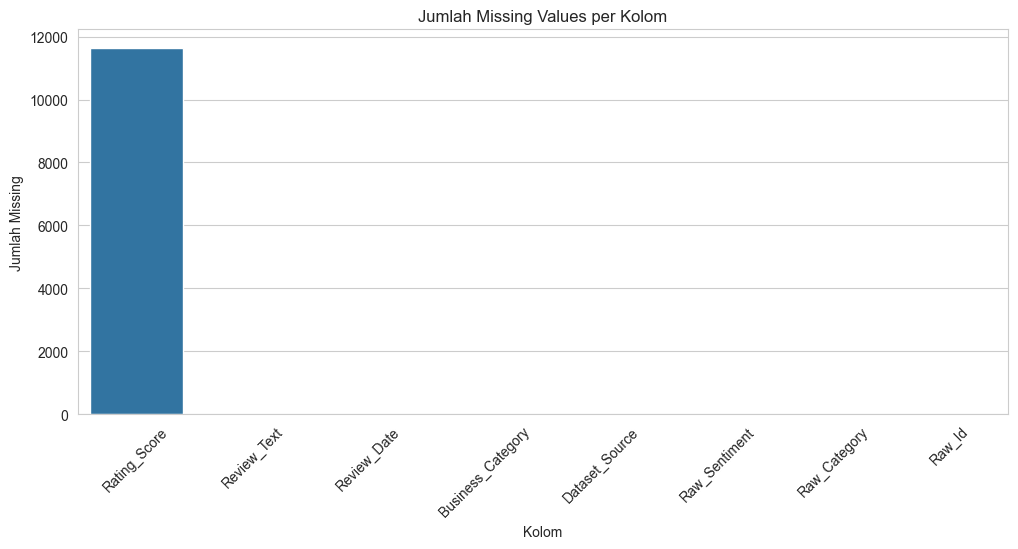

In [193]:
missing_values = df_all.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.title("Jumlah Missing Values per Kolom")
plt.xticks(rotation=45)
plt.ylabel("Jumlah Missing")
plt.xlabel("Kolom")
plt.show()

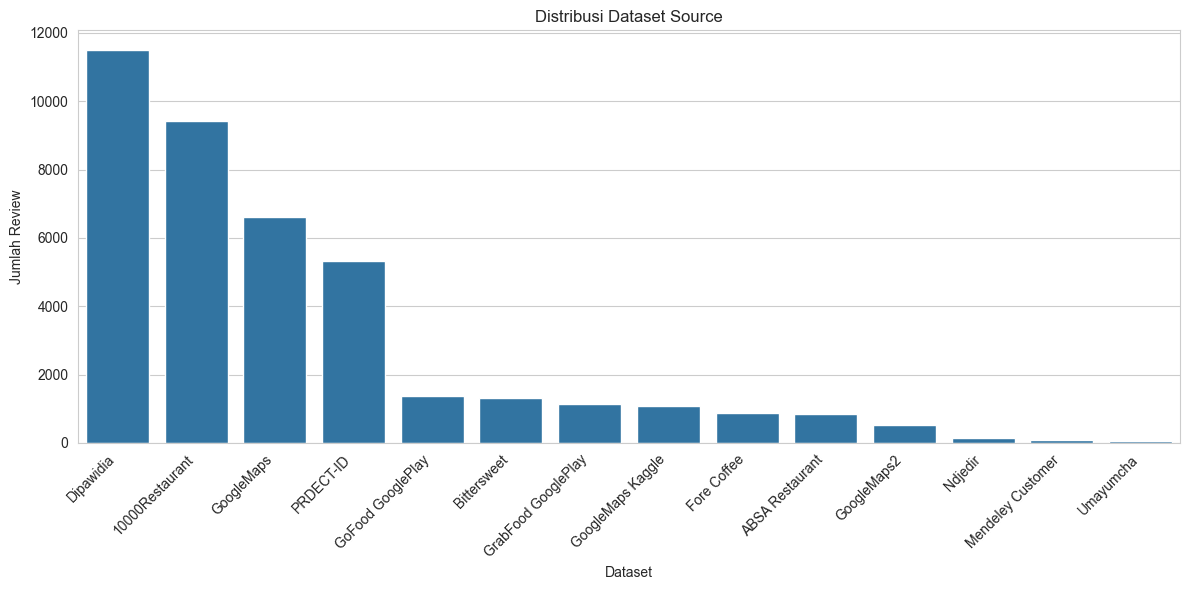

In [194]:
source_counts = df_all["Dataset_Source"].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=source_counts.index,
    y=source_counts.values
)

plt.title("Distribusi Dataset Source")
plt.xlabel("Dataset")
plt.ylabel("Jumlah Review")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

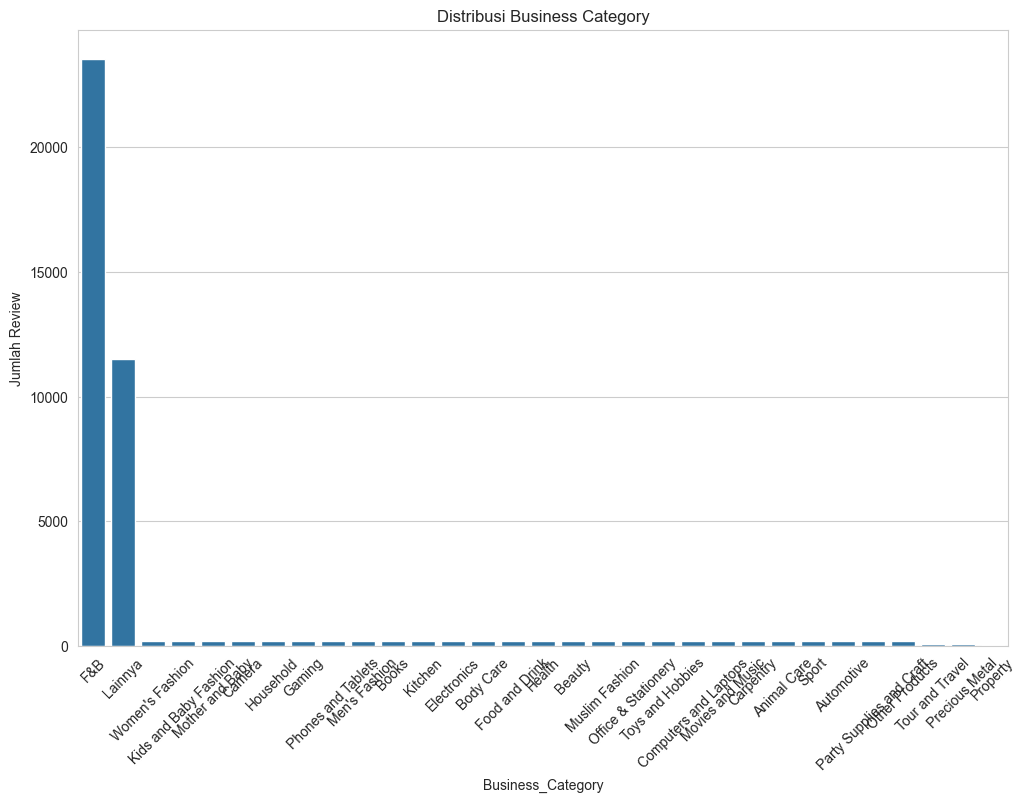

In [195]:
category_counts = df_all["Business_Category"].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.title("Distribusi Business Category")
plt.xticks(rotation=45)
plt.ylabel("Jumlah Review")
plt.show()

In [196]:
rating_df = df_all.dropna(subset=["Rating_Score"]).copy()
rating_df["Rating_Score"] = rating_df["Rating_Score"].astype(int)

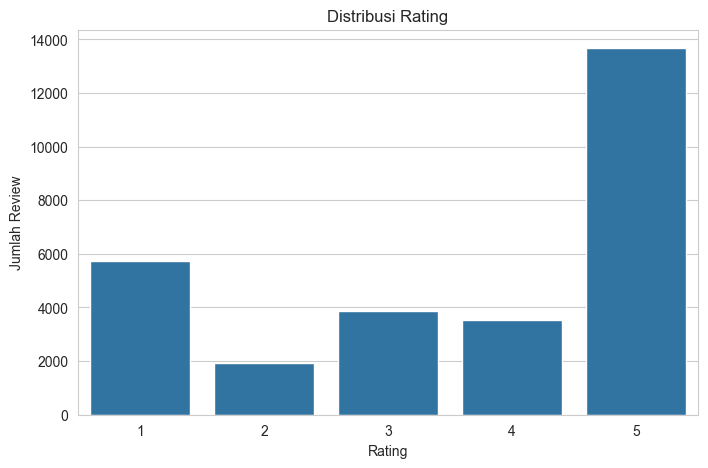

In [197]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Rating_Score",
    data=rating_df
)

plt.title("Distribusi Rating")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.show()

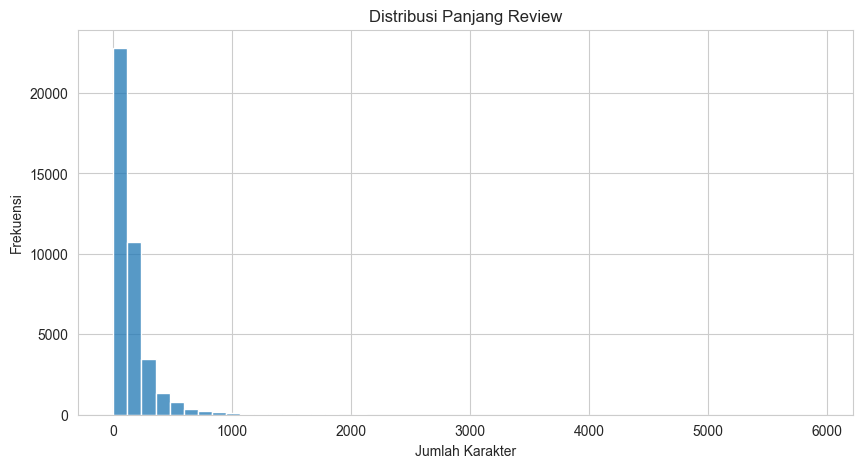

In [198]:
df_all["Review_Length"] = df_all["Review_Text"].str.len()

plt.figure(figsize=(10, 5))

sns.histplot(
    df_all["Review_Length"],
    bins=50
)

plt.title("Distribusi Panjang Review")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")
plt.show()

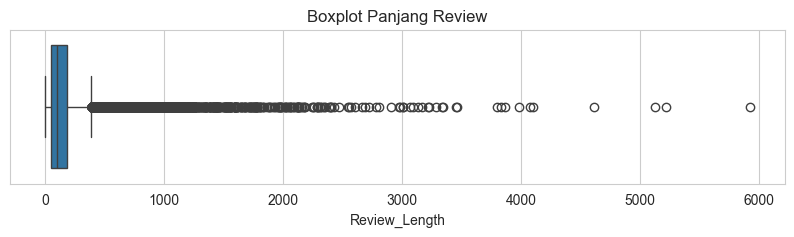

In [199]:
plt.figure(figsize=(10, 2))

sns.boxplot(
    x=df_all["Review_Length"]
)

plt.title("Boxplot Panjang Review")
plt.show()

In [200]:
duplicate_count = df_all.duplicated(subset=["Review_Text"]).sum()

print(f"Jumlah Duplicate Review: {duplicate_count}")
print(f"Persentase Duplicate: {(duplicate_count / len(df_all)) * 100:.2f}%")

Jumlah Duplicate Review: 722
Persentase Duplicate: 1.79%


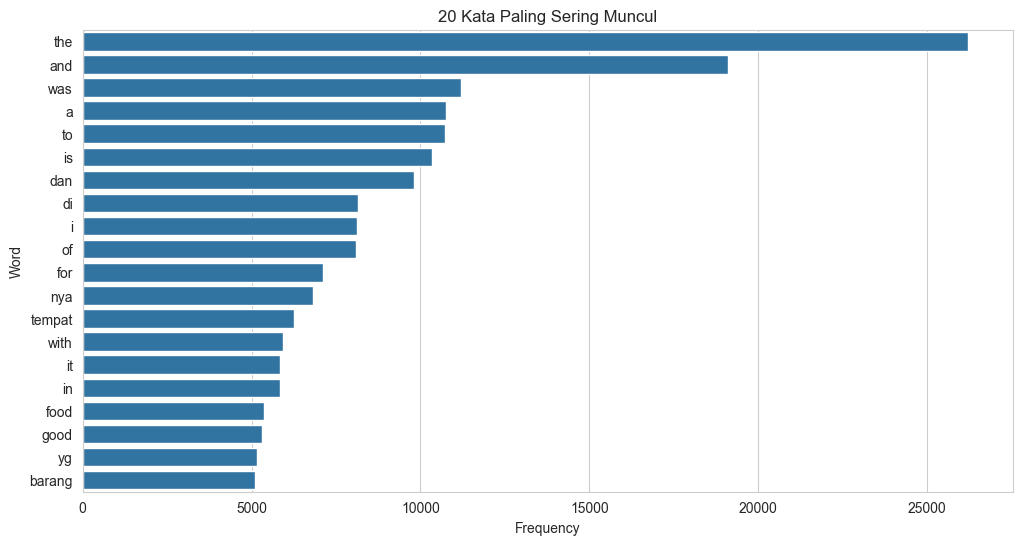

In [201]:
all_text = " ".join(df_all["Review_Text"].astype(str)).lower()

words = all_text.split()

word_freq = Counter(words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_words,
    x="Frequency",
    y="Word"
)

plt.title("20 Kata Paling Sering Muncul")
plt.show()

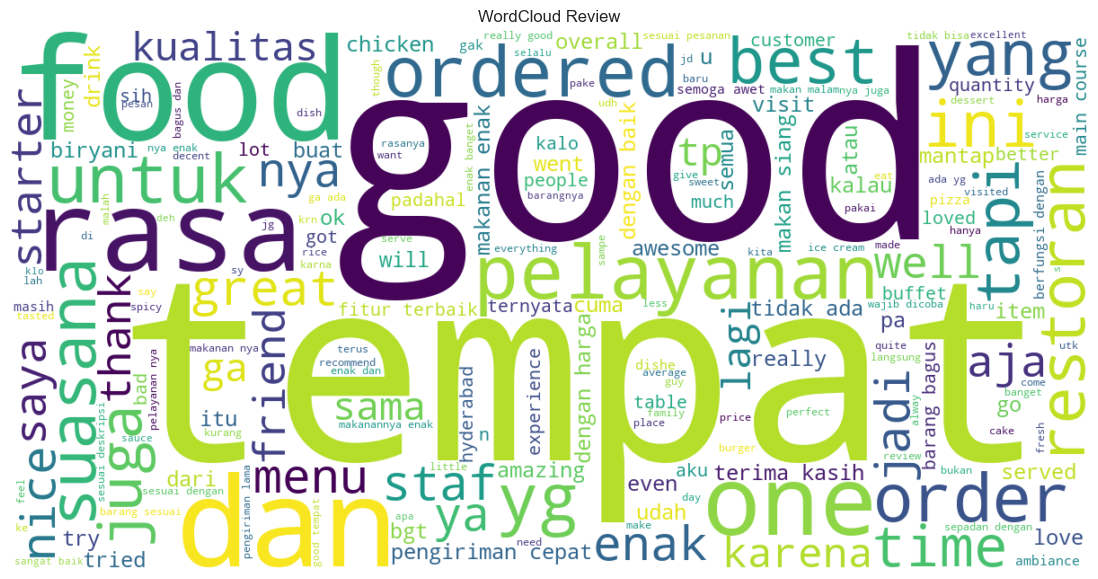

In [202]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Review")
plt.show()

In [203]:
df_all[[
    "Review_Text",
    "Dataset_Source",
    "Rating_Score"
]].sample(10)


,Review_Text,Dataset_Source,Rating_Score
23774,"food and rasa is fabulous, nothing there to co...",10000Restaurant,4
26630,i was so keen to try this tempat after the pic...,10000Restaurant,5
1854,Nasi matang merata 👍. Garansi terjamin. Nasiny...,Dipawidia,<NA>
12409,Enak dan rasanya konsisten dari dulu selalu en...,GoogleMaps,5
16831,"Great place, affordable drinks",GoogleMaps,5
38322,"sudah pesan GoFood, disuruh nunggu 30 menit, s...",GoFood GooglePlay,1
37773,Fore cj ada colokan gak ya,Fore Coffee,3
6854,toko rekomndasi karena official store barang n...,Dipawidia,<NA>
11924,mantap gaming soalnya selalu di traktir pas ke...,GoogleMaps,5
18127,"Kualitas barang bagus, harga relatif murah, ki...",PRDECT-ID,5


### Labeling

In [204]:
keyword_neutral = [
    'lumayan', 'biasa saja', 'biasa aja', 'cukup', 'standar', 'oke lah', 'okelah',
    'tidak buruk', 'tidak terlalu', 'bisa lah', 'bisalah', 'plus minus', 'sesuai harga',
    'masih oke', 'masih bisa', 'masih lumayan', 'belum tahu', 'belum tau']

keyword_rasa = [
    'rasa', 'enak', 'lezat', 'gurih', 'manis', 'asin', 'pahit', 'asam', 'nikmat', 'sedap',
    'hambar', 'segar', 'mantap', 'yummy', 'flavor', 'taste', 'bumbu', 'aroma', 'wangi',
    'harum', 'bau', 'pedas', 'crispy', 'renyah', 'tekstur', 'empuk', 'keras', 'lembut',
    'makanan', 'minuman', 'kopi', 'snack', 'matang', 'gosong', 'dingin', 'hangat', 'fresh',
    'juicy', 'creamy', 'aftertaste', 'porsi']

keyword_harga = [
    'harga', 'murah', 'mahal', 'worth', 'worthit', 'worth it', 'terjangkau', 'ekonomis',
    'hemat', 'diskon', 'promo', 'cashback', 'ongkir', 'gratis', 'sesuai harga',
    'overpriced', 'kemahalan', 'budget', 'biaya', 'bayar', 'tagihan', 'nominal', 'rupiah',
    'sebanding', 'tidak sebanding', 'mahal banget', 'murah meriah']

keyword_bentuk = [
    'bentuk', 'ukuran', 'kemasan', 'packaging', 'tampilan', 'desain', 'warna', 'model',
    'penampilan', 'fisik', 'material', 'bahan', 'kualitas', 'kokoh', 'kuat', 'rapuh',
    'tahan lama', 'awet', 'nyaman', 'pas', 'layar', 'body', 'casing', 'jahitan',
    'original', 'ori', 'asli', 'palsu', 'sesuai gambar', 'sesuai deskripsi', 'bagus',
    'jelek', 'rapi', 'bersih', 'kotor', 'besar', 'kecil', 'tipis', 'tebal', 'berat', 'ringan',
    'halus', 'kasar', 'lecet', 'penyok', 'retak', 'robek', 'pecah']

keyword_krisis = [
    'penipuan', 'tipu', 'bohong', 'palsu', 'rusak', 'cacat', 'hancur', 'kecewa',
    'tidak sesuai', 'tidak sama', 'berbeda', 'salah kirim', 'tidak sampai', 'hilang',
    'komplain', 'refund', 'return', 'retur', 'tidak berfungsi', 'tidak nyala', 'mati',
    'error', 'gagal', 'mengecewakan', 'parah', 'buruk', 'jangan beli', 'hindari',
    'barang tidak datang', 'barang hilang', 'pesanan tidak sesuai', 'uang tidak kembali',
    'tidak ori', 'lama banget', 'seller tidak merespon', 'pelayanan buruk', 'expired']

keyword_negasi = [
    'tidak', 'tak', 'bukan', 'belum', 'kurang', 'tanpa', 'gak', 'ga', 'nggak', 'ngga',
    'tdk', 'tp', 'tapi', 'namun', 'sayangnya', 'sayang']

keyword_sarcasm_positif = [
    'mantap', 'keren', 'jos', 'josss', 'perfect', 'sempurna', 'luar biasa', 'terbaik',
    'worth it', 'worthit', 'memuaskan', 'berkualitas', 'bintang lima', '5 bintang',
    'recommended banget', 'bagus banget', 'mantap banget', 'puas banget']

category_mapping_dataset_prdect = {
    'Food and Drink': 'F&B', 'Kitchen': 'F&B',
    'Computers and Laptops': 'Elektronik', 'Phones and Tablets': 'Elektronik',
    'Electronics': 'Elektronik', 'Camera': 'Elektronik', 'Gaming': 'Elektronik',
    "Women's Fashion": 'Fashion', "Men's Fashion": 'Fashion', 'Muslim Fashion': 'Fashion',
    'Kids and Baby Fashion': 'Fashion',
    'Health': 'Kesehatan & Kecantikan', 'Beauty': 'Kesehatan & Kecantikan',
    'Body Care': 'Kesehatan & Kecantikan',
    'Household': 'Perabotan', 'Carpentry': 'Perabotan',
    'Mother and Baby': 'Ibu & Bayi',
    'Animal Care': 'Perawatan Hewan',
    'Toys and Hobbies': 'Hobi & Hiburan', 'Movies and Music': 'Hobi & Hiburan',
    'Books': 'Hobi & Hiburan', 'Tour and Travel': 'Hobi & Hiburan', 'Sport': 'Hobi & Hiburan',
    'Automotive': 'Otomotif',
    'Office & Stationery': 'Perlengkapan Kantor',
    'Party Supplies and Craft': 'Kerajinan & Pesta',
    'Precious Metal': 'Lainnya', 'Property': 'Lainnya', 'Other Products': 'Lainnya'}


In [205]:
# Labeling data
LABELS = {'Positive', 'Negative', 'Neutral'}

RAW_SENTIMENT_MAP = {
    '0': 'Negative',
    '1': 'Positive',
    'positive': 'Positive',
    'positif': 'Positive',
    'negative': 'Negative',
    'negatif': 'Negative',
    'neutral': 'Neutral',
    'netral': 'Neutral',
}

def normalize_text(text):
    if not isinstance(text, str):
        return ''
    text = clean_text(text)
    return text.lower()


def contains_any(text, keywords):
    text = normalize_text(text)
    for kw in keywords:
        kw = normalize_text(kw)
        if kw and kw in text:
            return True
    return False


def to_int_rating(value):
    if pd.isna(value):
        return None
    try:
        return int(float(str(value).strip()))
    except Exception:
        return None


def normalize_label(label):
    label = normalize_text(label)
    return RAW_SENTIMENT_MAP.get(label, '')


def rating_to_sentiment(rating):
    if rating is None:
        return ''
    if rating in [1, 2]:
        return 'Negative'
    if rating == 3:
        return 'Neutral'
    if rating in [4, 5]:
        return 'Positive'
    return ''


def assign_sentiment(row):
    source = clean_text(row.get('Dataset_Source', ''))
    text = normalize_text(row.get('Review_Text', ''))
    raw_sentiment = normalize_label(row.get('Raw_Sentiment', ''))
    rating = to_int_rating(row.get('Rating_Score', None))

    if source == 'Dipawidia':
        if raw_sentiment in LABELS:
            return raw_sentiment
        if contains_any(text, keyword_neutral):
            return 'Neutral'
        sentiment_from_rating = rating_to_sentiment(rating)
        if sentiment_from_rating:
            return sentiment_from_rating
        return 'Neutral'

    sentiment_from_rating = rating_to_sentiment(rating)
    if sentiment_from_rating:
        return sentiment_from_rating

    if raw_sentiment in LABELS:
        return raw_sentiment

    return 'Neutral'


def assign_rating(row):
    rating = to_int_rating(row.get('Rating_Score', None))
    if rating is not None:
        return rating

    sentiment = normalize_label(row.get('Sentiment_Label', ''))
    if sentiment == 'Negative':
        return 2
    if sentiment == 'Neutral':
        return 3
    if sentiment == 'Positive':
        return 5

    return pd.NA


def detect_aspect(text):
    if not isinstance(text, str):
        return 'Lainnya'

    text_lower = normalize_text(text)

    scores = {
        'Rasa': sum(1 for kw in keyword_rasa if normalize_text(kw) in text_lower),
        'Harga': sum(1 for kw in keyword_harga if normalize_text(kw) in text_lower),
        'Bentuk': sum(1 for kw in keyword_bentuk if normalize_text(kw) in text_lower),
    }

    max_score = max(scores.values())

    if max_score == 0:
        return 'Lainnya'

    for aspect in ['Rasa', 'Harga', 'Bentuk']:
        if scores[aspect] == max_score:
            return aspect

    return 'Lainnya'


def assign_crisis(row):
    sentiment = normalize_label(row.get('Sentiment_Label', ''))
    rating = to_int_rating(row.get('Rating_Score', None))
    text = normalize_text(row.get('Review_Text', ''))

    is_negative = sentiment == 'Negative'
    is_low_rating = rating is not None and rating <= 2

    if (is_negative or is_low_rating) and contains_any(text, keyword_krisis):
        return 'Yes'
    return 'No'


def assign_business_category(row):
    source = clean_text(row.get('Dataset_Source', ''))
    raw_category = clean_text(row.get('Raw_Category', ''))
    current_category = clean_text(row.get('Business_Category', ''))

    if source == 'PRDECT-ID':
        return category_mapping_dataset_prdect.get(raw_category, 'Lainnya')

    return current_category if current_category else 'Lainnya'


def assign_sarcasm(row):
    if normalize_label(row.get('Sentiment_Label', '')) != 'Negative':
        return 'No'

    text = normalize_text(row.get('Review_Text', ''))
    if not text:
        return 'No'

    for keyword in keyword_sarcasm_positif:
        kw = normalize_text(keyword)
        if kw and kw in text:
            idx = text.find(kw)
            context_before = text[max(0, idx - 25):idx]
            if contains_any(context_before, keyword_negasi):
                return 'No'
            return 'Yes'

    return 'No'

In [206]:
def labeling_dataset(df):
    df = df.copy()

    required_cols = [
        "Review_Text",
        "Rating_Score",
        "Dataset_Source",
        "Business_Category",
        "Raw_Category",
        "Raw_Sentiment",
    ]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")
    
    if "Rating_Score_Original" not in df.columns:
        df["Rating_Score_Original"] = df["Rating_Score"]

    df["Sentiment_Label"] = df.apply(assign_sentiment, axis=1)

    df["Rating_Score"] = df.apply(assign_rating, axis=1)

    df["Review_Aspect"] = df["Review_Text"].apply(detect_aspect)

    df["Crisis_Flag"] = df.apply(assign_crisis, axis=1)

    df["Business_Category"] = df.apply(assign_business_category, axis=1)

    df["Is_Sarcasm"] = df.apply(assign_sarcasm, axis=1)

    return df

In [207]:
df_all_labeled = labeling_dataset(df_all)

print("\nSentiment distribution / Distribusi sentimen:")
sentiment_counts = df_all_labeled["Sentiment_Label"].value_counts(dropna=False)
for label, count in sentiment_counts.items():
    pct = (count / len(df_all_labeled)) * 100
    print(f"  {label:<10} : {count:>8,} ({pct:.1f}%)")


Sentiment distribution / Distribusi sentimen:
  Positive   :   22,937 (56.8%)
  Negative   :   13,421 (33.3%)
  Neutral    :    4,000 (9.9%)


In [208]:
# Melakukan balancing sentimen agar data seimbang dan diambil dari data yang terkecil
RANDOM_STATE = 42

sentiment_counts_before = df_all_labeled["Sentiment_Label"].value_counts()
min_label_count = sentiment_counts_before.min()

before_balancing = len(df_all_labeled)

balanced_parts = []

for label in sentiment_counts_before.index:
    label_data = df_all_labeled[df_all_labeled["Sentiment_Label"].eq(label)]
    balanced_parts.append(
        label_data.sample(
            n=min_label_count,
            random_state=RANDOM_STATE))

df_all_labeled = (
    pd.concat(balanced_parts, ignore_index=True)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True))

after_balancing = len(df_all_labeled)
removed_balancing = before_balancing - after_balancing

print("Distribusi sentimen sebelum balancing:")
print(sentiment_counts_before)

print("\nDistribusi sentimen setelah balancing:")
print(df_all_labeled["Sentiment_Label"].value_counts())

print(f"\nTotal sebelum balancing sentimen : {before_balancing:,} baris")
print(f"Total setelah balancing sentimen   : {after_balancing:,} baris")
print(f"Data yang dikurangi                : {removed_balancing:,} baris")

Distribusi sentimen sebelum balancing:
Sentiment_Label
Positive    22937
Negative    13421
Neutral      4000
Name: count, dtype: int64

Distribusi sentimen setelah balancing:
Sentiment_Label
Positive    4000
Negative    4000
Neutral     4000
Name: count, dtype: int64

Total sebelum balancing sentimen : 40,358 baris
Total setelah balancing sentimen   : 12,000 baris
Data yang dikurangi                : 28,358 baris


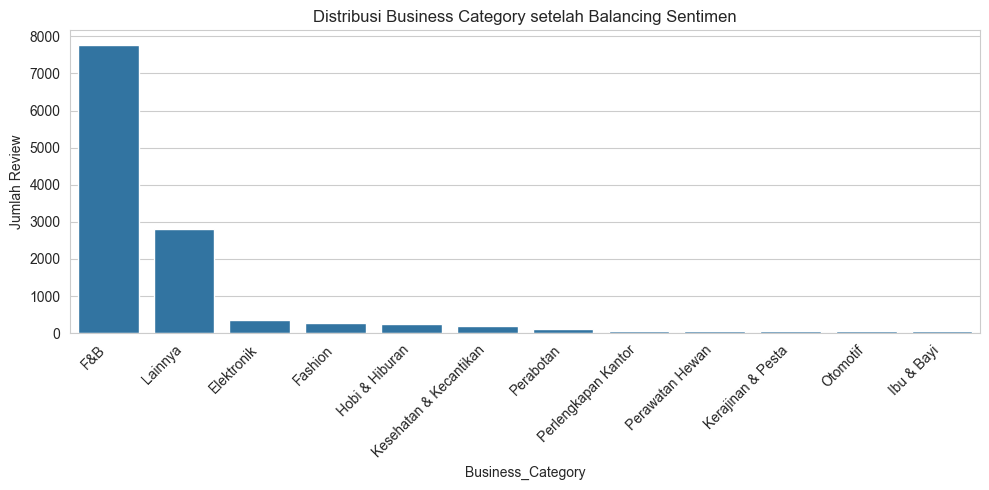

In [209]:
category_counts = df_all_labeled["Business_Category"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(
    x=category_counts.index,
    y=category_counts.values)

plt.title("Distribusi Business Category setelah Balancing Sentimen")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Jumlah Review")
plt.xlabel("Business_Category")
plt.tight_layout()
plt.show()


### Data Splitting



In [210]:
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42

df_train_val, df_test = train_test_split(
    df_all_labeled,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_all_labeled["Sentiment_Label"]
)

validation_ratio = VALIDATION_SIZE / (TRAIN_SIZE + VALIDATION_SIZE)

df_train, df_validation = train_test_split(
    df_train_val,
    test_size=validation_ratio,
    random_state=RANDOM_STATE,
    stratify=df_train_val["Sentiment_Label"]
)

df_train = df_train.reset_index(drop=True)
df_validation = df_validation.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"Data train      : {len(df_train):,} baris")
print(f"Data validation : {len(df_validation):,} baris")
print(f"Data test       : {len(df_test):,} baris")

print("\nDistribusi sentimen train:")
print(df_train["Sentiment_Label"].value_counts())

print("\nDistribusi sentimen validation:")
print(df_validation["Sentiment_Label"].value_counts())

print("\nDistribusi sentimen test:")
print(df_test["Sentiment_Label"].value_counts())


Data train      : 8,399 baris
Data validation : 1,801 baris
Data test       : 1,800 baris

Distribusi sentimen train:
Sentiment_Label
Negative    2800
Neutral     2800
Positive    2799
Name: count, dtype: int64

Distribusi sentimen validation:
Sentiment_Label
Positive    601
Neutral     600
Negative    600
Name: count, dtype: int64

Distribusi sentimen test:
Sentiment_Label
Positive    600
Negative    600
Neutral     600
Name: count, dtype: int64


### Data Preprocessing

In [211]:
def cleaning_dataset(df):
    df = df.copy()
    info = {}

    info["total_awal_raw"] = len(df)
    before_cols = df.columns.tolist()

    # Normalisasi teks 
    df["Review_Text"] = df["Review_Text"].apply(clean_text)

    # Hapus review kosong
    mask_text_empty = df["Review_Text"].eq("")
    info["teks_kosong"] = int(mask_text_empty.sum())
    df = df.loc[~mask_text_empty].copy()

    # Data Rating Dipawidia dikeep
    mask_rating_valid = df["Rating_Score"].notna() | df["Dataset_Source"].eq("Dipawidia")
    info["hapus_rating"] = int((~mask_rating_valid).sum())
    df = df.loc[mask_rating_valid].copy()

    # Standardisasi tipe data rating
    if "Rating_Score" in df.columns:
        df["Rating_Score"] = pd.to_numeric(df["Rating_Score"], errors="coerce").astype("Int64")

    # Hapus duplikasi
    dup_subset = ["Review_Text", "Review_Date", "Rating_Score", "Dataset_Source"]
    before_dup = len(df)
    df = df.drop_duplicates(subset=dup_subset).copy()
    info["hapus_duplikat"] = before_dup - len(df)

    # Hapus review yang terlalu pendek
    before_short = len(df)
    mask_long_enough = df["Review_Text"].str.split().str.len().fillna(0).ge(2)
    df = df.loc[mask_long_enough].copy()
    info["hapus_pendek"] = before_short - len(df)

    df = df.reset_index(drop=True)

    info["total_akhir"] = len(df)
    info["total_noise"] = info["total_awal_raw"] - info["total_akhir"]
    info["noise_pct"] = round((info["total_noise"] / info["total_awal_raw"]) * 100, 2) if info["total_awal_raw"] else 100

    after_cols = df.columns.tolist()
    info["kolom_awal"] = before_cols
    info["kolom_akhir"] = after_cols
    info["kolom_baru"] = [c for c in after_cols if c not in before_cols]
    info["kolom_hilang"] = [c for c in before_cols if c not in after_cols]

    return df, info


In [212]:
slang_dict = {
    "yg": "yang", "dg": "dengan", "dgn": "dengan", "utk": "untuk",
    "tdk": "tidak", "gak": "tidak", "ga": "tidak", "nggak": "tidak",
    "ngga": "tidak", "gk": "tidak", "bgt": "banget", "bgtt": "banget",
    "tp": "tapi", "tpi": "tapi", "krn": "karena", "karna": "karena",
    "aja": "saja", "jg": "juga", "jd": "jadi", "sdh": "sudah",
    "udh": "sudah", "blm": "belum", "msh": "masih", "mksh": "terima kasih",
    "makasih": "terima kasih", "thanks": "terima kasih", "thx": "terima kasih",
    "recomend": "recommended", "rekomen": "recommended", "ori": "original",
    "mantap": "bagus", "keren": "bagus", "jos": "bagus"
}

preserve_terms = {
    "original", "palsu", "garansi", "refund", "return", "komplain",
    "diskon", "promo", "cashback", "ongkir", "packaging", "seller",
    "rating", "review", "baterai", "charger", "wifi", "bluetooth",
    "android", "gaming", "premium", "fashion", "enak", "lezat",
    "gurih", "renyah", "crispy", "manis", "pahit", "asam",
    "pedas", "asin", "empuk", "keras", "lembut", "murah",
    "mahal", "hemat", "cepat", "lambat", "rusak", "bagus",
    "buruk", "jelek", "puas", "kecewa", "hancur", "cacat",
    "tipu", "hilang", "error", "gagal"
}

custom_stopwords = {
    "wah", "wow", "hehe", "haha", "hihi", "dong", "nih", "sih", "deh", "lah",
    "ini", "itu", "sini", "sana", "saya", "aku", "kami", "kita", "mereka", "anda",
    "hari", "minggu", "bulan", "tahun", "jam", "menit", "kemarin", "sekarang", "nanti",
    "order", "pesan", "beli", "produk", "barang", "item", "paket", "dapat", "terima",
    "datang", "tiba", "sampai", "kirim", "dikirim", "foto", "gambar", "deskripsi"
}

important_negations = {"tidak", "tak", "bukan", "belum", "jangan", "gak", "ga", "nggak", "ngga", "tdk"}

factory_stop = StopWordRemoverFactory()
sastrawi_stop = set(factory_stop.get_stop_words())

all_stopwords = (sastrawi_stop | custom_stopwords) - important_negations

factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()


In [213]:
stem_cache = {}

def stem_cached(word):
    if word not in stem_cache:
        stem_cache[word] = stemmer.stem(word)
    return stem_cache[word]

def preprocess_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""

    URL_PATTERN = re.compile(r"http\S+|www\S+|https\S+")
    NON_ALNUM_PATTERN = re.compile(r"[^a-z0-9\s]")
    MULTISPACE_PATTERN = re.compile(r"\s+")
    NUMBER_PATTERN = re.compile(r"\b\d+\b")

    # Lowercase + hapus URL
    text = text.lower()
    text = URL_PATTERN.sub(" ", text)

    # Pertahankan huruf, angka, spasi
    text = NON_ALNUM_PATTERN.sub(" ", text)
    text = NUMBER_PATTERN.sub(" ", text)
    text = MULTISPACE_PATTERN.sub(" ", text).strip()

    tokens = text.split()

    # Slang normalization
    tokens = [slang_dict.get(tok, tok) for tok in tokens]

    cleaned_tokens = []
    for tok in tokens:
        if tok in all_stopwords:
            continue
        if len(tok) <= 1:
            continue

        # Simpan istilah penting
        if tok in preserve_terms:
            cleaned_tokens.append(tok)
        else:
            cleaned_tokens.append(stem_cached(tok))

    return re.sub(r"\s+", " ", " ".join(cleaned_tokens)).strip()


def preprocessing_dataset(df):
    df = df.copy()
    before_cols = df.columns.tolist()

    df["Review_Text_Processed"] = df["Review_Text"].apply(preprocess_text)

    # Hapus hasil proses yang kosong
    mask_non_empty = df["Review_Text_Processed"].astype(str).str.strip().ne("")
    removed_empty = int((~mask_non_empty).sum())
    df = df.loc[mask_non_empty].copy()

    df = df.reset_index(drop=True)

    after_cols = df.columns.tolist()
    col_info = {
        "kolom_awal": before_cols,
        "kolom_akhir": after_cols,
        "kolom_baru": [c for c in after_cols if c not in before_cols],
        "kolom_hilang": [c for c in before_cols if c not in after_cols],
    }

    return df, removed_empty, col_info


def print_column_change(info, title=""):
    if title:
        print(f"\n{title}")
    print(f"    Kolom awal   : {len(info['kolom_awal'])}")
    print(f"    Kolom akhir  : {len(info['kolom_akhir'])}")
    print(f"    Kolom baru   : {info['kolom_baru']}")
    print(f"    Kolom hilang : {info['kolom_hilang']}")

In [214]:
df_train_clean, info_clean_train = cleaning_dataset(df_train)
df_validation_clean, info_clean_validation = cleaning_dataset(df_validation)
df_test_clean, info_clean_test = cleaning_dataset(df_test)

print(f"    Train setelah cleaning      : {len(df_train_clean):,} baris")
print(f"    Validation setelah cleaning : {len(df_validation_clean):,} baris")
print(f"    Test setelah cleaning       : {len(df_test_clean):,} baris")
print(f"    Noise train                 : {info_clean_train['noise_pct']}%")
print(f"    Noise validation            : {info_clean_validation['noise_pct']}%")
print(f"    Noise test                  : {info_clean_test['noise_pct']}%")

print_column_change(info_clean_train, title="[Train] Perubahan struktur kolom setelah cleaning")
print_column_change(info_clean_validation, title="[Validation] Perubahan struktur kolom setelah cleaning")
print_column_change(info_clean_test, title="[Test] Perubahan struktur kolom setelah cleaning")

start_time = time.time()

df_train_final, empty_train, col_info_train = preprocessing_dataset(df_train_clean)
df_validation_final, empty_validation, col_info_validation = preprocessing_dataset(df_validation_clean)
df_test_final, empty_test, col_info_test = preprocessing_dataset(df_test_clean)

elapsed = round(time.time() - start_time, 2)

print(f"    Train final                  : {len(df_train_final):,} baris")
print(f"    Validation final             : {len(df_validation_final):,} baris")
print(f"    Test final                   : {len(df_test_final):,} baris")
print(f"    Baris kosong setelah proses  : {empty_train + empty_validation + empty_test:,}")
print(f"    Waktu proses preprocessing   : {elapsed} detik")

print_column_change(col_info_train, title="[Train] Perubahan struktur kolom setelah preprocessing")
print_column_change(col_info_validation, title="[Validation] Perubahan struktur kolom setelah preprocessing")
print_column_change(col_info_test, title="[Test] Perubahan struktur kolom setelah preprocessing")


    Train setelah cleaning      : 8,391 baris
    Validation setelah cleaning : 1,799 baris
    Test setelah cleaning       : 1,798 baris
    Noise train                 : 0.1%
    Noise validation            : 0.11%
    Noise test                  : 0.11%

[Train] Perubahan struktur kolom setelah cleaning
    Kolom awal   : 14
    Kolom akhir  : 14
    Kolom baru   : []
    Kolom hilang : []

[Validation] Perubahan struktur kolom setelah cleaning
    Kolom awal   : 14
    Kolom akhir  : 14
    Kolom baru   : []
    Kolom hilang : []

[Test] Perubahan struktur kolom setelah cleaning
    Kolom awal   : 14
    Kolom akhir  : 14
    Kolom baru   : []
    Kolom hilang : []
    Train final                  : 8,374 baris
    Validation final             : 1,795 baris
    Test final                   : 1,793 baris
    Baris kosong setelah proses  : 26
    Waktu proses preprocessing   : 11.79 detik

[Train] Perubahan struktur kolom setelah preprocessing
    Kolom awal   : 14
    Kolom akhir  :

In [215]:
FINAL_COLUMNS = [
    "Review_Text",
    "Review_Text_Processed",
    "Review_Date",
    "Rating_Score",
    "Business_Category",
    "Sentiment_Label",
    "Review_Aspect",
    "Crisis_Flag",
    "Is_Sarcasm"
]


In [216]:
df_train_final = df_train_final[FINAL_COLUMNS].copy()
df_validation_final = df_validation_final[FINAL_COLUMNS].copy()
df_test_final = df_test_final[FINAL_COLUMNS].copy()

print("\nDATASET TRAIN")
display(df_train_final.head())

print("\nDATASET VALIDATION")
display(df_validation_final.head())

print("\nDATASET TEST")
display(df_test_final.head())



DATASET TRAIN


,Review_Text,Review_Text_Processed,Review_Date,Rating_Score,Business_Category,Sentiment_Label,Review_Aspect,Crisis_Flag,Is_Sarcasm
0,"Mantap, pengiriman seminggu untuk elektrolit i...",bagus kirim minggu elektrolit cepat,unknown,5,Lainnya,Positive,Rasa,No,No
1,1 menu kami datang pada saat makan sudah seles...,menu makan selesai kasir tidak ramah tidak ban...,2024-05-19T07:03:15.972Z,1,F&B,Negative,Harga,No,No
2,domino's doesn't live up to the standards any ...,domino doesn live up to the standards any more...,5/7/2019 13:59,1,F&B,Negative,Lainnya,Yes,No
3,*over rated? i feel it is. desserts are good* ...,over rated feel it is desserts are good food a...,4/24/2019 1:17,2,F&B,Negative,Rasa,No,No
4,"pesan makanan lamaaa smpai 2 jam, sya beralin ...",makan lamaaa smpai sya alin applikasi tks grab...,2026-04-01 21:31:34,1,F&B,Negative,Rasa,No,No



DATASET VALIDATION


,Review_Text,Review_Text_Processed,Review_Date,Rating_Score,Business_Category,Sentiment_Label,Review_Aspect,Crisis_Flag,Is_Sarcasm
0,never disappoints me. always up to my expectat...,never disappoints me always up to my expectati...,3/13/2019 12:35,3,F&B,Neutral,Lainnya,No,No
1,barang masih kurang gir yg kecil,gir,unknown,2,Lainnya,Negative,Bentuk,No,No
2,the chocolate room as name suggests should hav...,the chocolate room as name suggests should hav...,5/7/2018 20:21,4,F&B,Positive,Lainnya,No,No
3,"barang sesuai gambar,bagus speakernya,fungsi s...",sesuai bagus speakernya fungsi tombol kecewa s...,unknown,2,Lainnya,Negative,Bentuk,Yes,No
4,Musik terlalu keras sehingga tidak nyaman.,musik keras tidak nyaman,2025-11-02T12:12:16.715Z,2,F&B,Negative,Rasa,No,No



DATASET TEST


,Review_Text,Review_Text_Processed,Review_Date,Rating_Score,Business_Category,Sentiment_Label,Review_Aspect,Crisis_Flag,Is_Sarcasm
0,superb rasa but little delay in getting produc...,superb but little delay in getting product to ...,6/10/2018 1:39,5,F&B,Positive,Rasa,No,No
1,Bagus tempat santai,bagus santai,2019-04-28T07:33:39.398Z,1,F&B,Negative,Bentuk,No,No
2,"aplikasi grab food jelek sekarang, pesen makan...",aplikasi grab food jelek sen makan proses anta...,2026-03-09 00:03:43,1,F&B,Negative,Rasa,Yes,No
3,kualitas nya bagus,kualitas bagus,unknown,5,Lainnya,Positive,Bentuk,No,No
4,ada penyok,penyok,unknown,2,Lainnya,Negative,Bentuk,No,No


In [217]:
# validasi kpi
final_combined = pd.concat([df_train_final, df_validation_final, df_test_final], ignore_index=True)

important_fields = [
    "Review_Text",
    "Review_Text_Processed",
    "Rating_Score",
    "Business_Category",
    "Sentiment_Label",
    "Review_Aspect",
]

missing_important = final_combined[important_fields].isna().sum().sum()
empty_important = final_combined[important_fields].astype(str).apply(lambda col: col.str.strip().eq("")).sum().sum()
total_important = len(final_combined) * len(important_fields)
completeness_pct = round(((total_important - missing_important - empty_important) / total_important) * 100, 2)

noise_total_awal = info_clean_train["total_awal_raw"] + info_clean_validation["total_awal_raw"] + info_clean_test["total_awal_raw"]
noise_total = info_clean_train["total_noise"] + info_clean_validation["total_noise"] + info_clean_test["total_noise"]
noise_pct = round((noise_total / noise_total_awal) * 100, 2) if noise_total_awal else 100

rating_sentiment_check = final_combined.copy()
rating_sentiment_check["Rating_Score"] = pd.to_numeric(rating_sentiment_check["Rating_Score"], errors="coerce")
rating_sentiment_check["Sentiment_From_Rating"] = rating_sentiment_check["Rating_Score"].apply(lambda rating: rating_to_sentiment(int(rating)) if pd.notna(rating) else "")
valid_check = rating_sentiment_check["Sentiment_From_Rating"].ne("")
label_agreement_pct = round((rating_sentiment_check.loc[valid_check, "Sentiment_Label"] == rating_sentiment_check.loc[valid_check, "Sentiment_From_Rating"]).mean() * 100, 2) if valid_check.any() else 0

kpi_result = pd.DataFrame({
    "KPI": [
        "Tingkat Noise data setelah Cleaning",
        "Konsisten Labeling",
        "Kelengkapan Dataset field penting",
    ],
    "Target": ["< 10%", ">= 85%", ">= 95%"],
    "Hasil": [f"{noise_pct}%", f"{label_agreement_pct}%", f"{completeness_pct}%"],
    "Status": [
        "Lulus" if noise_pct < 10 else "Belum Lulus",
        "Lulus" if label_agreement_pct >= 85 else "Belum Lulus",
        "Lulus" if completeness_pct >= 95 else "Belum Lulus"]})

display(kpi_result)

print("\nDistribusi sentimen final:")
print(final_combined["Sentiment_Label"].value_counts())

print("\nDistribusi kategori final:")
print(final_combined["Business_Category"].value_counts())


,KPI,Target,Hasil,Status
0,Tingkat Noise data setelah Cleaning,< 10%,0.1%,Lulus
1,Konsisten Labeling,>= 85%,100.0%,Lulus
2,Kelengkapan Dataset field penting,>= 95%,100.0%,Lulus



Distribusi sentimen final:
Sentiment_Label
Positive    3995
Negative    3992
Neutral     3975
Name: count, dtype: int64

Distribusi kategori final:
Business_Category
F&B                       7741
Lainnya                   2791
Elektronik                 342
Fashion                    271
Hobi & Hiburan             254
Kesehatan & Kecantikan     185
Perabotan                  120
Perlengkapan Kantor         55
Perawatan Hewan             54
Kerajinan & Pesta           52
Otomotif                    52
Ibu & Bayi                  45
Name: count, dtype: int64


In [218]:
OUTPUT_DIR = os.path.join(DATA_DIR, "processed-dataset")

os.makedirs(OUTPUT_DIR, exist_ok=True)

df_train_final.to_csv(os.path.join(OUTPUT_DIR, "train_final.csv"), index=False, encoding="utf-8-sig")
df_validation_final.to_csv(os.path.join(OUTPUT_DIR, "validation_final.csv"), index=False, encoding="utf-8-sig")
df_test_final.to_csv(os.path.join(OUTPUT_DIR, "test_final.csv"), index=False, encoding="utf-8-sig")
